In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

In [11]:
df = pd.read_csv("noisy_curvefit_data.csv")
df

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [12]:
print (df.shape)
print (df.shape[0])
print (df.shape[1])

print (df.head())
print (df.tail())

print (df.columns)

(100, 6)
100
6
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


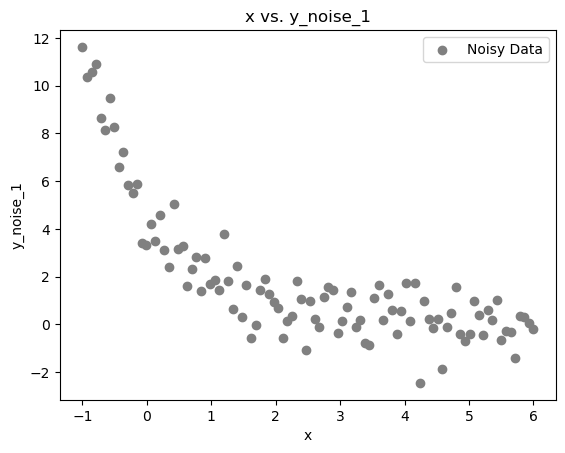

In [13]:
plt.scatter(df["x"], df["y_noise_1"], color= "gray", label = "Noisy Data")
plt.xlabel("x")
plt.ylabel ("y_noise_1")
plt.title("x vs. y_noise_1")
plt.legend()
plt.show()

Fit: y = 4.71 * e^(-0.92*x)
Reduced chi-squared: 0.79


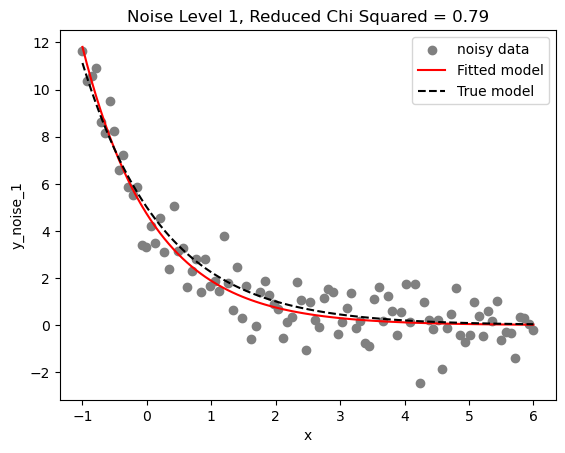

In [14]:
def model(x, A, k): 
    return A * np.exp(-k * x)

x = df["x"]
y_noise_1 = df ["y_noise_1"]

p0 = [1,1]

popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt

print (f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f}*x)")

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

print (f"Reduced chi-squared: {chi2_reduced:.2f}")

plt.scatter(x,y_noise_1, color="gray", label = "noisy data")
plt.plot (x, model(x, A_fit, k_fit), color="red", label = "Fitted model")
plt.plot(x, model(x,5,0.8), color = "black", linestyle="--", label ="True model")

plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.title(f"Noise Level 1, Reduced Chi Squared = {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [15]:
def model(x,A,k):
    return A * np.exp(-k *x)

def fit_model(x,y):
    p0 = [1,1]
    popt, pcov = curve_fit(model, x,y, p0=p0)
    A_fit, k_fit = popt
    residuals = y- model(x,A_fit,k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return popt, chi2_reduced

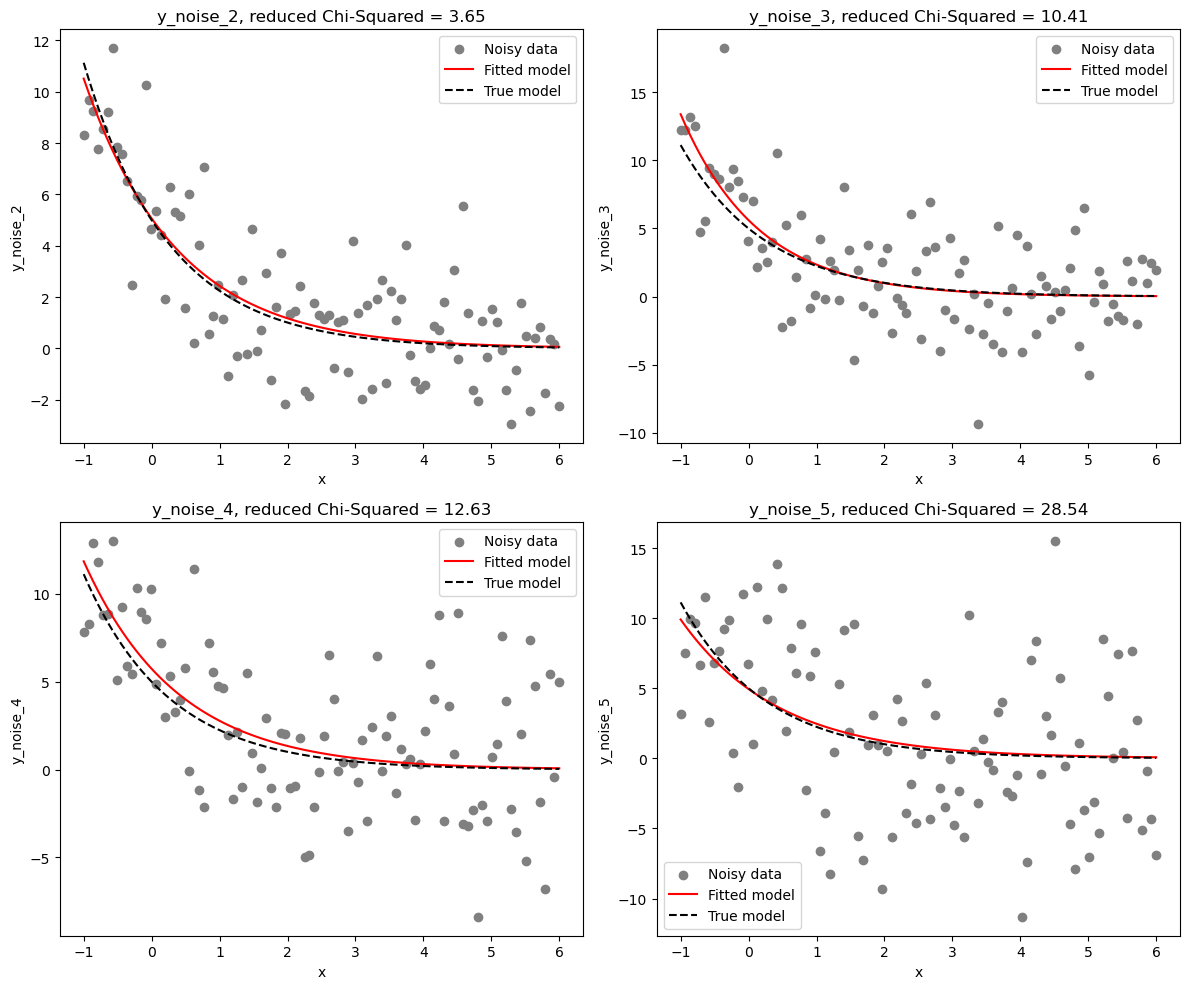

In [17]:
x = df["x"]

noise_columns = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(noise_columns):
    y = df[col]

    popt, chi2_reduced = fit_model(x,y)
    A_fit, k_fit = popt

    axes[i].scatter(x,y, color="gray", label="Noisy data")
    axes[i].plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
    axes[i].plot(x, model(x,5,0.8), color="black", linestyle="--", label= "True model")
    axes[i].set_title(f"{col}, reduced Chi-Squared = {chi2_reduced:.2f}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

    

In [18]:
#1. As the noise increases the data points become more spread out and closer to the true curve. Therefore the red and black lines match eachother much better but the fit becomes less precise because the noise makes it harder for curve_fit to determine values for A and k 
#2. As noise increases the reduced chi squared becomes larger. This is because the residuls between the noise and fitted model end up increasing. There fore the model describes the data less closely. 

In [22]:
results = []

noise_columns = ["y_noise_1", "y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

for i, col in enumerate(noise_columns, start=1): 
    y= df[col]
    popt, chi2_reduced = fit_model(x,y)
    A_fit, k_fit = popt

    results.append({"Noise level":i, "A fit": A_fit, "k_fit": k_fit, "Reduced chi-squared": chi2_reduced})

results_df = pd.DataFrame(results)
results_df

,Noise level,A fit,k_fit,Reduced chi-squared
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124


In [23]:
results_df.to_csv("noisy_parameters.csv", index=False)